In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
# get all csv in /csv
csv_folder = "./csv"
# csv_folder = "./csv_medium_size"
csv_list = [x for x in os.listdir(csv_folder) if x.endswith(".csv")]
print(csv_list)

['analyzed_results_20230802_10kx.csv', 'analyzed_results_20230802_1kx.csv', 'analyzed_results_20230802_9kx.csv', 'analyzed_results_20241003_5kx.csv', 'analyzed_results_20241011_5kx.csv']


In [3]:
# excluded data, txt
excluded_data = pd.read_csv(csv_folder+'/bad_mask.txt', header=None)
# transpose
excluded_data = excluded_data.T
# convert to list
excluded_data = excluded_data[0].tolist()
# remove excluded data, if excluded data is part of Label
excluded_data_str = list(map(str, excluded_data))  # convert all items to strings
excluded_pattern = '|'.join(excluded_data_str)  # create a regex pattern
print(excluded_pattern)

233|273|283| 


In [4]:
# prepare data
data_combined = pd.DataFrame(columns=['Label', 'Major', 'kx', 'major(um)', 'Feret', 'Feret(um)'])
for csv_file in csv_list:
    # get kx from csv file name
    kx = csv_file.split('_')[-1].split('k')[0]
    # if get pixel size from kx: 5kx - 45pixel/um, 9kx - 81pixel/um, 10kx - 90pixel/um
    # 1kx - 9pixel/um
    if kx == '1':
        pixel_size = 1/9
    elif kx == '5':
        pixel_size = 1/45
    elif kx == '9':
        pixel_size = 1/81
    elif kx == '10':
        pixel_size = 1/90
    else:
        print('kx not found')
        break
    # read csv
    data = pd.read_csv(csv_folder+'/'+csv_file)
    # use the regex pattern to filter the DataFrame
    data = data[~data['Label'].str.contains(excluded_pattern, na=False)]
    for i in range(len(data)):
        label = data.iloc[i]['Label']
        major = data.iloc[i]['Major']
        major_um = major * pixel_size
        feret = data.iloc[i]['Feret']
        feret_um = feret * pixel_size
        new_pd = pd.DataFrame([[label, major, kx, major_um, feret, feret_um]], columns=['Label', 'Major', 'kx', 'major(um)', 'Feret', 'Feret(um)'])
        data_combined = pd.concat([data_combined, new_pd])

In [5]:
data_combined.head()

,Label,Major,kx,major(um),Feret,Feret(um)
0,image152.tif,105.602,10,1.173356,106.231,1.180344
0,image153.tif,9.392,1,1.043556,10.296,1.144000
0,image153.tif,9.629,1,1.069889,10.198,1.133111
0,image153.tif,10.304,1,1.144889,10.770,1.196667
0,image153.tif,10.673,1,1.185889,11.180,1.242222


In [6]:
# remove outliers
data_combined = data_combined[data_combined['major(um)'] > 0.7]
data_combined = data_combined[data_combined['major(um)'] < 1.5]
# only keep middle (100-x)% data
keep_x = 5
data_combined = data_combined[data_combined['major(um)'] > data_combined['major(um)'].quantile(keep_x/200)]
data_combined = data_combined[data_combined['major(um)'] < data_combined['major(um)'].quantile(1-keep_x/200)]
data_combined = data_combined[data_combined['Feret(um)'] > 0.7]

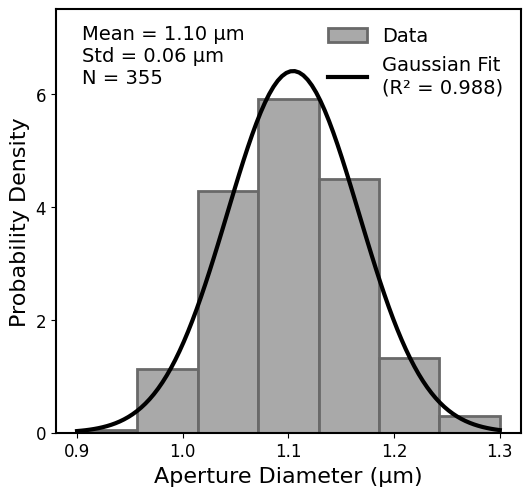

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, kstest, anderson
from sklearn.metrics import r2_score

plt.figure(figsize=(6,5.5))

color = 'darkgray'
outline_color = 'dimgray'

# Histogram settings
bin_range = (0.9, 1.3)
# bin_range = (min(data_combined['major(um)'])-0.05, max(data_combined['major(um)']))
num_bins = 7

# Extract data
data = data_combined['major(um)']

# Fit a normal distribution to the data
mu, sigma = norm.fit(data)

# Generate x values for the fitted curve
x = np.linspace(bin_range[0], bin_range[1], 100)
pdf = norm.pdf(x, mu, sigma)  # Gaussian curve

# Compute R² (coefficient of determination)
hist_values, bin_edges = np.histogram(data, bins=num_bins, range=bin_range, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Compute bin centers
expected_pdf = norm.pdf(bin_centers, mu, sigma)  # Expected Gaussian values at bin centers
r2 = r2_score(hist_values, expected_pdf)

# Perform Kolmogorov-Smirnov test
ks_stat, ks_pval = kstest(data, 'norm', args=(mu, sigma))

# Perform Anderson-Darling test
ad_result = anderson(data, dist='norm')

# Plot histogram
plt.hist(data, bins=num_bins, range=bin_range, edgecolor=outline_color, 
         color=color, alpha=1, density=True, linewidth=2, label="Data")

# Overlay Gaussian fit
plt.plot(x, pdf, 'k-', linewidth=3, label="Gaussian Fit\n(R² = {:.3f})".format(r2))

# Add text about mean, std, and goodness of fit
N = len(data)
text_str = (
    f"Mean = {mu:.2f} μm\n"
    f"Std = {sigma:.2f} μm\n"
    f"N = {N}\n"
)
plt.text(0.905, 5.8, text_str, fontsize=14)

# Axis labels
plt.xlabel('Aperture Diameter (μm)', fontsize=16)
plt.ylabel('Probability Density', fontsize=16)

# Adjust tick label size
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=12)

# Add legend
plt.legend(frameon=False, fontsize=14, loc='upper right')

# limits
# plt.xlim(1.05, 1.36)
plt.ylim(0, 7.5)

# Font sizes
ax.tick_params(axis='both', which='major', labelsize=12)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=16)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=16)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(14)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
ax.locator_params(axis='y', nbins=6)
ax.locator_params(axis='x', nbins=6)

# Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('Aperture_Diameter_Distribution.png', format='png', dpi=900, transparent=True, bbox_inches='tight')


# # Print goodness of fit statistics
# print("Gaussian Fit Parameters:")
# print(f"Mean (μ) = {mu:.3f}, Std (σ) = {sigma:.3f}")
# print(f"R² = {r2:.3f} (Goodness of Fit)")
